In [1]:
import os
from pyspark.sql import SparkSession
os.environ["PYSPARK_SUBMIT_ARGS"] = "--packages io.graphframes:graphframes-spark4_2.13:0.11.0 pyspark-shell"
spark = SparkSession.builder.master("local[*]").appName("graph").getOrCreate()
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from graphframes import GraphFrame
data_dir = "../dataset/e-shop clothing 2008.csv"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/14 23:21:57 WARN Utils: Your hostname, DESKTOP-UQF5BSK, resolves to a loopback address: 127.0.1.1; using 172.24.225.163 instead (on interface eth0)
26/04/14 23:21:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/leonid/miniconda3/envs/bigdata_env/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/leonid/.ivy2.5.2/cache
The jars for the packages stored in: /home/leonid/.ivy2.5.2/jars
io.graphframes#graphframes-spark4_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-3d0dfb30-186b-49ee-8e7e-efb6ae43794a;1.0
	confs: [default]
	found io.graphframes#graphframes-spark4_2.13;0.11.0 in central
	found io.graphframes#graphframes-graphx-spark4_2.13;0.11.0 in central
:: resolution report :: resolve 233ms :: artifacts dl 6

In [2]:
df = spark.read.csv(data_dir, inferSchema=True, header=True, sep=";")
df = df.drop("year", "month", "day", "country")
df.show(5)

+-----+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|order|session ID|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|
+-----+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|    1|         1|                     1|                    A13|     1|       5|                1|   28|      2|   1|
|    2|         1|                     1|                    A16|     1|       6|                1|   33|      2|   1|
|    3|         1|                     2|                     B4|    10|       2|                1|   52|      1|   1|
|    4|         1|                     2|                    B17|     6|       6|                2|   38|      2|   1|
|    5|         1|                     2|                     B8|     4|       3|                2|   52|      1|   1|
+-----+----------+----------------------+-------

In [3]:
from pyspark.sql import functions as F
vertices = df.drop("session ID", "order").drop_duplicates()
vertices = vertices.withColumn("id", F.monotonically_increasing_id())
vertices.write.parquet("verts", mode="overwrite")
vertices = spark.read.parquet("verts")
edge_c = ["id", "order", "session ID"]
lhs = df.join(F.broadcast(vertices), on = vertices.columns[:-1], how = "left").select(*edge_c).withColumnsRenamed({col: col + "_l" for col in edge_c})
rhs = df.join(F.broadcast(vertices), on = vertices.columns[:-1], how = "left").select(*edge_c).withColumnsRenamed({col: col + "_r" for col in edge_c})
edges = lhs.join(rhs, on = [lhs["session ID_l"] == rhs["session ID_r"], lhs.order_l == (rhs.order_r - 1)], how = "inner")
edges = edges.drop(*lhs.columns[1:]).drop(*rhs.columns[1:]).withColumnsRenamed({"id_l":"src", "id_r":"dst"})
print(edges.count())
edges = edges.groupBy(edges.columns).count().withColumnRenamed("count", "weight")
print(edges.count())
percentile_95 = edges.select(F.percentile("weight", 0.95)).collect()[0][0]
print(percentile_95)
edges = edges.filter(edges.weight >= percentile_95)
#min = edges.select(F.min("weight")).collect()[0][0]
#max = edges.select(F.max("weight")).collect()[0][0]
edges = edges.withColumn("weight", F.log("weight"))
edges = edges.where(F.col("src") != F.col("dst"))
print(edges.count())
edges.show(20)
print(vertices.count())
vertices.show(20)

141448


20508


28.0


966


+---+---+------------------+
|src|dst|            weight|
+---+---+------------------+
|202|148| 4.844187086458591|
| 18|102|4.1588830833596715|
|104|200| 3.367295829986474|
|116|149| 3.367295829986474|
|181| 46| 4.343805421853684|
|216|113|3.6635616461296463|
|128|  6|3.4657359027997265|
|195|210|3.4965075614664802|
| 43|202| 4.189654742026425|
| 55|181| 3.713572066704308|
|149| 62|3.9889840465642745|
|165| 70| 4.060443010546419|
|  6| 42|3.9889840465642745|
|  4| 61|4.1588830833596715|
|174|187| 4.290459441148391|
|181| 12|3.7612001156935624|
|146| 49|3.6375861597263857|
|154|171| 3.332204510175204|
|204| 77|3.4011973816621555|
| 87|194|4.6443908991413725|
+---+---+------------------+
only showing top 20 rows
218
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page| id|
+----------------------+-----------------------+------+--------

In [4]:
graph = GraphFrame(vertices, edges)
graph = graph.dropIsolatedVertices()
# Show vertices and edges 
print("Edges:") 
graph.vertices.show(truncate=False) 
print("Verts:") 
graph.edges.show() 

Edges:


+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|id |page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|
+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|26 |1                     |A36                    |1     |6       |1                |33   |2      |2   |
|29 |4                     |P80                    |7     |3       |1                |28   |2      |5   |
|65 |4                     |P9                     |4     |3       |2                |23   |2      |1   |
|191|1                     |A4                     |3     |2       |2                |38   |2      |1   |
|19 |2                     |B23                    |7     |2       |1                |38   |2      |2   |
|54 |3                     |C4                     |4     |2       |1                |48   |1      |1   |
|0  |4                     |P51               

+---+---+------------------+
|src|dst|            weight|
+---+---+------------------+
|202|148| 4.844187086458591|
| 18|102|4.1588830833596715|
|104|200| 3.367295829986474|
|116|149| 3.367295829986474|
|181| 46| 4.343805421853684|
|216|113|3.6635616461296463|
|128|  6|3.4657359027997265|
|195|210|3.4965075614664802|
| 43|202| 4.189654742026425|
| 55|181| 3.713572066704308|
|149| 62|3.9889840465642745|
|165| 70| 4.060443010546419|
|  6| 42|3.9889840465642745|
|  4| 61|4.1588830833596715|
|174|187| 4.290459441148391|
|181| 12|3.7612001156935624|
|146| 49|3.6375861597263857|
|154|171| 3.332204510175204|
|204| 77|3.4011973816621555|
| 87|194|4.6443908991413725|
+---+---+------------------+
only showing top 20 rows


# Pagerank

In [5]:
pr = graph.pageRank(maxIter=100)

26/04/14 23:22:37 WARN ShippableVertexPartitionOps: Joining two VertexPartitions with different indexes is slow.
26/04/14 23:22:56 WARN PageRank: Returned DataFrame is persistent and materialized!


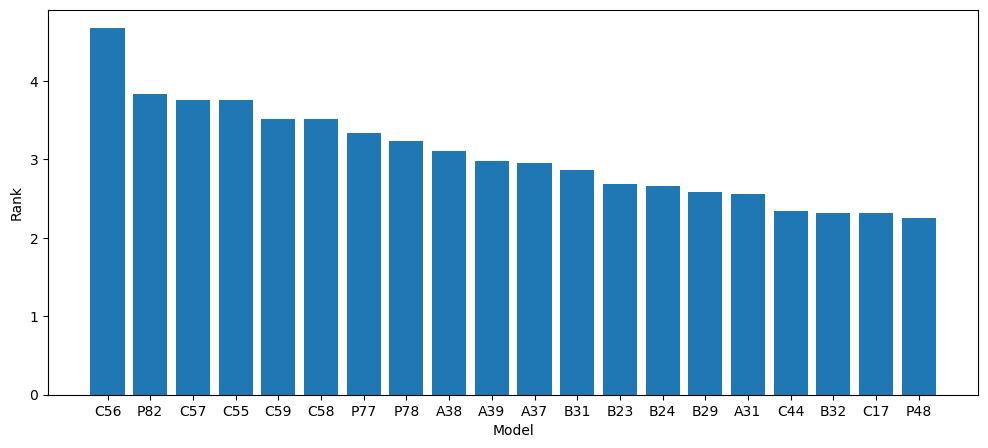

In [6]:
import matplotlib.pyplot as plt
output = pr.vertices.orderBy("pagerank", ascending=False)
pd_out = output.select("pagerank", "page 2 (clothing model)").toPandas()
plt.figure(figsize=(12, 5))
plt.bar(pd_out["page 2 (clothing model)"][0:20], pd_out["pagerank"][0:20])
plt.xlabel("Model")
plt.ylabel("Rank")
plt.show()

# Connected Components

In [7]:
spark.sparkContext.setCheckpointDir("graphframes-checkpoint") 
components = graph.connectedComponents() 

26/04/14 23:22:57 WARN ConnectedComponents: Algorithm 'graphframes' is deprecated and will be removed in a future release. Using 'two_phase' instead.
26/04/14 23:23:49 WARN TwoPhase$: Returned DataFrame is persistent and materialized!


In [8]:
components.show()

+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---------+
| id|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|component|
+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---------+
| 26|                     1|                    A36|     1|       6|                1|   33|      2|   2|        0|
| 29|                     4|                    P80|     7|       3|                1|   28|      2|   5|        0|
| 65|                     4|                     P9|     4|       3|                2|   23|      2|   1|        0|
|191|                     1|                     A4|     3|       2|                2|   38|      2|   1|        0|
| 19|                     2|                    B23|     7|       2|                1|   38|      2|   2|        0|
| 54|                     3|                     C4|     4|       2|    

### Triangle cycles

In [9]:
motifs = graph.find("(a)-[e1]->(b); (b)-[e2]->(c); (c)-[e3]->(a)") 
print("Motifs (Triangles):") 
motifs.show(truncate=False) 
print(motifs.count())
loops = motifs.select([F.col("a.page 2 (clothing model)").alias("p1"),  F.col("b.page 2 (clothing model)").alias("p2"), F.col("c.page 2 (clothing model)").alias("p3")])
loops.show()

Motifs (Triangles):


+---------------------------------+-----------------------------+---------------------------------+------------------------------+---------------------------------+------------------------------+
|a                                |e1                           |b                                |e2                            |c                                |e3                            |
+---------------------------------+-----------------------------+---------------------------------+------------------------------+---------------------------------+------------------------------+
|{202, 3, C5, 11, 2, 1, 48, 1, 1} |{202, 148, 4.844187086458591}|{148, 3, C6, 6, 2, 1, 33, 2, 1}  |{148, 151, 4.442651256490317} |{151, 3, C7, 13, 3, 1, 48, 1, 1} |{151, 202, 3.828641396489095} |
|{202, 3, C5, 11, 2, 1, 48, 1, 1} |{202, 148, 4.844187086458591}|{148, 3, C6, 6, 2, 1, 33, 2, 1}  |{148, 195, 3.4657359027997265}|{195, 3, C9, 6, 3, 1, 48, 1, 1}  |{195, 202, 3.4011973816621555}|
|{116, 1, A12, 2, 4,

+---+---+---+
| p1| p2| p3|
+---+---+---+
| C5| C6| C7|
| C5| C6| C9|
|A12|A16|A13|
|A12|A16|A15|
|A12|A16| A4|
|A12|A16|A17|
|A12|A16|A11|
|B13|B11|B15|
|B13|B11|B10|
|B13|B11| B4|
|B13|B11|B12|
|B13|B11|B17|
|B13|B11|B14|
|B13|B11|B16|
| B3|B13| B4|
| B3|B13| B1|
| B3|B13|B10|
|A16|A11|A15|
|A16|A11|A14|
|A16|A11|A12|
+---+---+---+
only showing top 20 rows


### Visualization

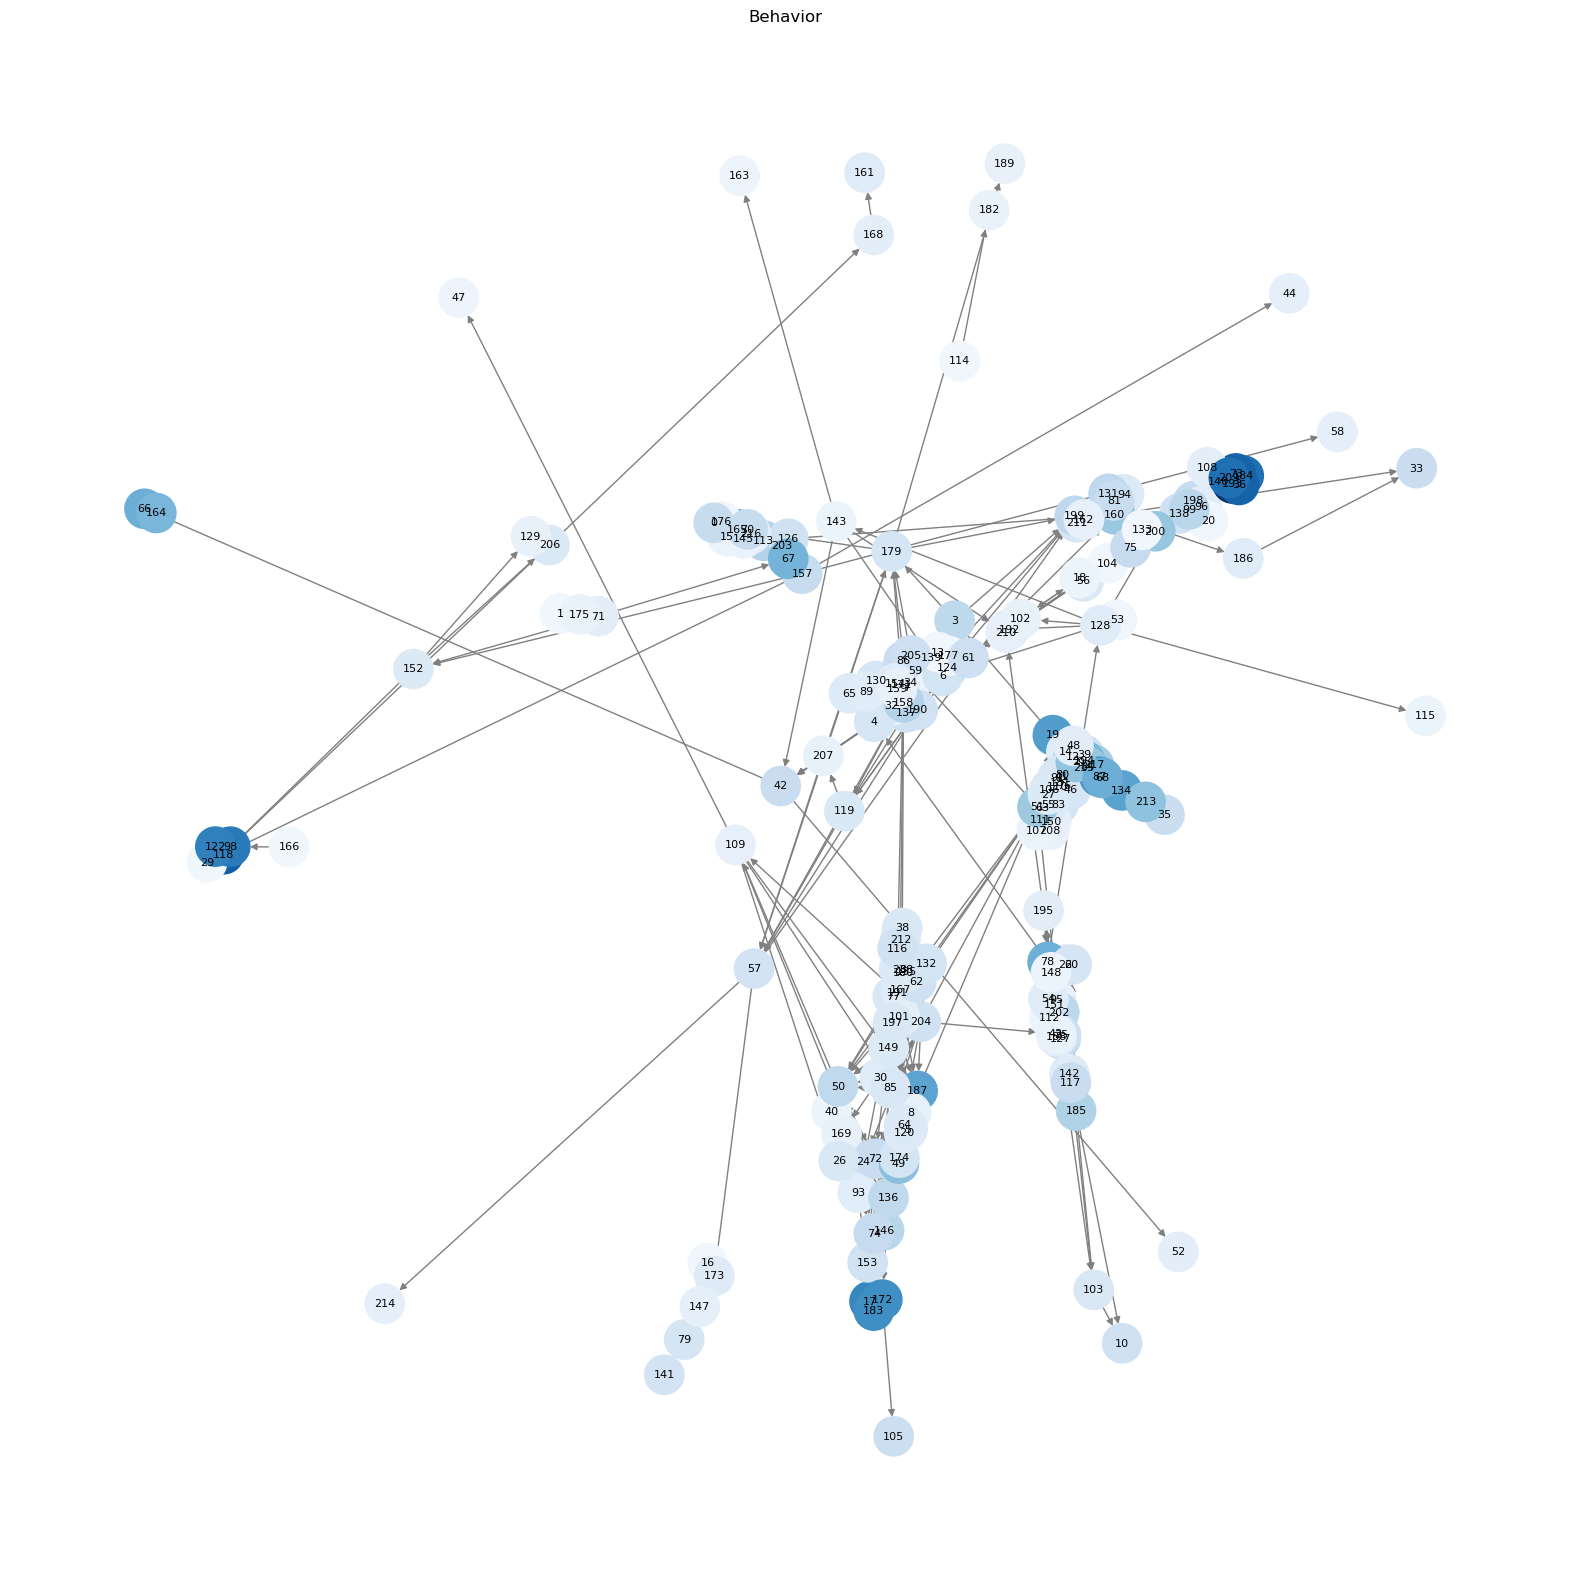

In [10]:
import matplotlib.pyplot as plt
pd_verts = pr.vertices.toPandas()
pd_edges = edges.toPandas()
my_graph = nx.DiGraph()
max_pr = pd_verts["pagerank"].max()
for _, v in pd_verts.iterrows():
    my_graph.add_node(v["id"], rank=(v["pagerank"] / max_pr))

for _, e in pd_edges.iterrows():
    my_graph.add_edge(e["src"], e["dst"], weight = e["weight"])

node_colors = [plt.cm.Blues(my_graph.nodes[n]["rank"]) for n in my_graph.nodes] 
pos = nx.spring_layout(my_graph, seed=42) 
plt.figure(figsize=(20, 20)) 
nx.draw_networkx(my_graph, pos ,with_labels=True, node_size=800, node_color=node_colors, font_size=8, edge_color="gray") 
plt.title("Behavior") 
plt.axis("off") 
plt.show()


# PIC and brief analysis

In [11]:
pic = graph.powerIterationClustering(k = 10, maxIter=50, weightCol="weight")

26/04/14 23:24:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [12]:
pic_verts = graph.vertices.join(pic, on = "id", how = "left").orderBy("cluster", ascending = True)
pic_verts.show()

+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+-------+
| id|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|cluster|
+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+-------+
| 68|                     2|                    B32|     6|       5|                1|   38|      2|   2|      0|
|208|                     2|                     B7|     6|       3|                1|   38|      2|   1|      0|
| 72|                     1|                    A33|     1|       5|                1|   38|      2|   2|      0|
|191|                     1|                     A4|     3|       2|                2|   38|      2|   1|      0|
| 87|                     2|                    B31|     9|       5|                1|   57|      1|   2|      0|
|167|                     1|                     A1|     8|       1|                1|  

In [13]:
from pyspark.sql.window import Window
def analyze(vertex_data):
    mode_cols = vertex_data.columns[1:-1]
    print("MODE:")
    mode = vertex_data.groupBy("cluster").agg(*[F.mode(col) for col in mode_cols]).join(vertex_data.groupBy("cluster").count(), on = "cluster")
    mode.show()
    print("PROFILE:")
    profile = vertex_data.groupBy("cluster").agg(
        F.avg("price").alias("avg_price"),
        F.mode("price").alias("top_price"),
        F.stddev("price").alias("price_std"),
        F.count("*").alias("size"),
        F.countDistinct("colour").alias("colour_diversity"),
        F.countDistinct("page 2 (clothing model)").alias("model_diversity"),
        F.countDistinct("page 1 (main category)").alias("cluster_categories"),
        F.mode("colour").alias("top_colour"))
    profile.show()
    w = Window.partitionBy("cluster").orderBy(F.rand())
    print("RANDOM SAMPLES:")
    vertex_data.withColumn("rn", F.row_number().over(w)).filter("rn <= 5").show()
    vertex_data.groupBy("cluster", "colour", "model photography").count().show()

In [14]:
analyze(pic_verts)

MODE:


+-------+----------------------------+-----------------------------+------------+--------------+-----------------------+-----------+-------------+----------+-----+
|cluster|mode(page 1 (main category))|mode(page 2 (clothing model))|mode(colour)|mode(location)|mode(model photography)|mode(price)|mode(price 2)|mode(page)|count|
+-------+----------------------------+-----------------------------+------------+--------------+-----------------------+-----------+-------------+----------+-----+
|      0|                           1|                          B13|           2|             1|                      1|         38|            2|         1|   75|
|      1|                           4|                          P53|           2|             6|                      2|         38|            1|         3|    1|
|      2|                           3|                          C50|           6|             2|                      1|         28|            2|         3|   12|
|      3|       

+-------+------------------+---------+------------------+----+----------------+---------------+------------------+----------+
|cluster|         avg_price|top_price|         price_std|size|colour_diversity|model_diversity|cluster_categories|top_colour|
+-------+------------------+---------+------------------+----+----------------+---------------+------------------+----------+
|      1|              38.0|       38|              NULL|   1|               1|              1|                 1|         2|
|      6|              42.0|       33| 9.664367542679654|  21|               9|             21|                 2|        14|
|      3|              23.0|       23|              NULL|   1|               1|              1|                 1|        11|
|      5|39.206896551724135|       48| 8.415034633426853|  29|              10|             29|                 2|         9|
|      9|              41.5|       38|10.535653752852738|  12|               7|             12|                 2|    

+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+-------+---+
| id|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|cluster| rn|
+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+-------+---+
| 48|                     2|                    B22|     2|       2|                1|   67|      1|   2|      0|  1|
| 83|                     2|                     B9|     1|       3|                1|   48|      2|   1|      0|  2|
|116|                     1|                    A12|     2|       4|                1|   38|      2|   1|      0|  3|
| 88|                     1|                     A8|     3|       3|                1|   62|      1|   1|      0|  4|
|101|                     1|                    A14|     3|       5|                1|   60|      1|   1|      0|  5|
|182|                     4|                    P53|    

+-------+------+-----------------+-----+
|cluster|colour|model photography|count|
+-------+------+-----------------+-----+
|      5|    12|                1|    2|
|      5|     4|                2|    1|
|      7|    11|                2|    1|
|      0|     1|                1|    7|
|      9|     2|                1|    1|
|      7|     7|                1|    2|
|      0|     2|                2|    1|
|      0|     1|                2|    1|
|      7|    12|                2|    1|
|      5|     5|                2|    1|
|      8|    14|                1|    3|
|      8|    11|                2|    1|
|      0|     7|                1|    1|
|      2|     2|                2|    1|
|      2|    13|                2|    1|
|      4|     2|                1|    6|
|      5|    14|                1|    3|
|      6|     7|                1|    1|
|      8|    14|                2|    1|
|      5|     6|                1|    3|
+-------+------+-----------------+-----+
only showing top

# Inspection of Connected Components

In [15]:
analyze(components.withColumnRenamed("component", "cluster"))

MODE:


+-------+----------------------------+-----------------------------+------------+--------------+-----------------------+-----------+-------------+----------+-----+
|cluster|mode(page 1 (main category))|mode(page 2 (clothing model))|mode(colour)|mode(location)|mode(model photography)|mode(price)|mode(price 2)|mode(page)|count|
+-------+----------------------------+-----------------------------+------------+--------------+-----------------------+-----------+-------------+----------+-----+
|      0|                           4|                          B13|           2|             1|                      1|         38|            2|         1|  194|
|    114|                           4|                          P53|          11|             6|                      2|         23|            1|         3|    2|
+-------+----------------------------+-----------------------------+------------+--------------+-----------------------+-----------+-------------+----------+-----+

PROFILE:


+-------+-----------------+---------+------------------+----+----------------+---------------+------------------+----------+
|cluster|        avg_price|top_price|         price_std|size|colour_diversity|model_diversity|cluster_categories|top_colour|
+-------+-----------------+---------+------------------+----+----------------+---------------+------------------+----------+
|      0|41.58762886597938|       38|11.969955979955147| 194|              14|            194|                 4|         2|
|    114|             30.5|       23|10.606601717798213|   2|               2|              2|                 1|        11|
+-------+-----------------+---------+------------------+----+----------------+---------------+------------------+----------+

RANDOM SAMPLES:


+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+-------+---+
| id|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|cluster| rn|
+---+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+-------+---+
|133|                     3|                    C52|     2|       6|                1|   38|      2|   3|      0|  1|
| 67|                     4|                    P60|    14|       2|                1|   28|      2|   4|      0|  2|
|143|                     3|                    C26|    14|       3|                1|   28|      2|   2|      0|  3|
| 85|                     1|                    A17|     2|       6|                1|   62|      1|   1|      0|  4|
|  1|                     4|                    P57|     4|       1|                1|   43|      1|   4|      0|  5|
|182|                     4|                    P53|    

+-------+------+-----------------+-----+
|cluster|colour|model photography|count|
+-------+------+-----------------+-----+
|      0|     1|                1|    7|
|      0|     7|                1|    8|
|      0|     4|                2|    9|
|      0|     3|                2|    2|
|      0|     4|                1|   15|
|      0|     9|                1|   11|
|      0|     6|                2|   13|
|      0|    14|                1|   15|
|      0|     8|                1|    2|
|      0|     6|                1|   13|
|      0|     3|                1|   15|
|      0|     2|                1|   29|
|      0|     5|                2|    3|
|      0|    11|                1|    4|
|      0|    12|                1|    7|
|      0|    13|                1|    6|
|      0|    14|                2|    8|
|      0|     1|                2|    2|
|      0|     2|                2|    9|
|      0|    12|                2|    4|
+-------+------+-----------------+-----+
only showing top

# Inspection of label propagation

In [16]:
lp = graph.labelPropagation(maxIter=10)

26/04/14 23:24:33 WARN LabelPropagation: Returned DataFrame is persistent and materialized!


In [17]:
print(lp.count())
analyze(lp.withColumnRenamed("label", "cluster"))

196
MODE:
+-------+----------------------------+-----------------------------+------------+--------------+-----------------------+-----------+-------------+----------+-----+
|cluster|mode(page 1 (main category))|mode(page 2 (clothing model))|mode(colour)|mode(location)|mode(model photography)|mode(price)|mode(price 2)|mode(page)|count|
+-------+----------------------------+-----------------------------+------------+--------------+-----------------------+-----------+-------------+----------+-----+
|      0|                           4|                          P50|          14|             5|                      1|         28|            2|         3|    5|
|     98|                           4|                          P78|           7|             2|                      1|         28|            1|         5|    3|
|    145|                           4|                          P47|          14|             4|                      1|         28|            2|         3|    1|
|     

# Simple recommender

In [18]:
paths = graph.find("(a)-[e1]->(b); (b)-[e2]->(c); (c)-[e3]->(d);")

transitions = paths.select(
        F.col("a.id").alias("n1"),
        F.col("b.id").alias("n2"),
        F.col("c.id").alias("n3"),
        F.col("d.id").alias("next"),
        F.col("e3.weight").alias("score")
)

transitions.show()


+---+---+---+----+------------------+
| n1| n2| n3|next|             score|
+---+---+---+----+------------------+
|202|148| 95| 195|  4.23410650459726|
|202|148| 95| 185| 3.367295829986474|
|202|148| 95|  78|3.5553480614894135|
|202|148|202| 151| 4.912654885736052|
|202|148|202| 142|3.4011973816621555|
|202|148|202|  78| 4.454347296253507|
|202|148|202|  25|3.8918202981106265|
|202|148|202| 127|3.6635616461296463|
|202|148|202| 185|  4.04305126783455|
|202|148|202|  60|3.5263605246161616|
|202|148|202| 117|3.6888794541139363|
|202|148|202| 195|4.2626798770413155|
|202|148|202|  95|3.9512437185814275|
|202|148|202| 148| 4.844187086458591|
|202|148|151|  25| 3.713572066704308|
|202|148|151|  78| 3.713572066704308|
|202|148|151| 185|3.6888794541139363|
|202|148|151|  95|4.2626798770413155|
|202|148|151| 195|4.1588830833596715|
|202|148|151| 202| 3.828641396489095|
+---+---+---+----+------------------+
only showing top 20 rows
